# Sobre

### Nosso objetivo é criar um modelo de Machine Learning Simples utilizando Scikit-Learning que tenta “adivinhar” a nota dos candidatos em matemática (NU_NOTA_MT).


- Como variável de entrada, utilizaremos as colunas do questionário sócio econômico, acrescridas de cor/raça, tipo de escola, estado da prova e estado civil. Ou seja, utilize as colunas:  
NU_ANO, Q001, Q002, Q003, Q004, Q005, Q006, Q007, Q008, Q009, Q010, Q011, Q012, Q013, Q014, Q015, Q016, Q017, Q018, Q019, Q020, Q021, Q022, Q023, Q024, Q025, Q026, Q027, TP_ESTADO_CIVIL, TP_COR_RACA, TP_ESCOLA, CO_UF_PROVA.

---
## Sobre o modelo de ML
Para nossa abordagem, vamos criar N modelos de ML com Random Forest, e gerar uma Floresta final com todas as árvores



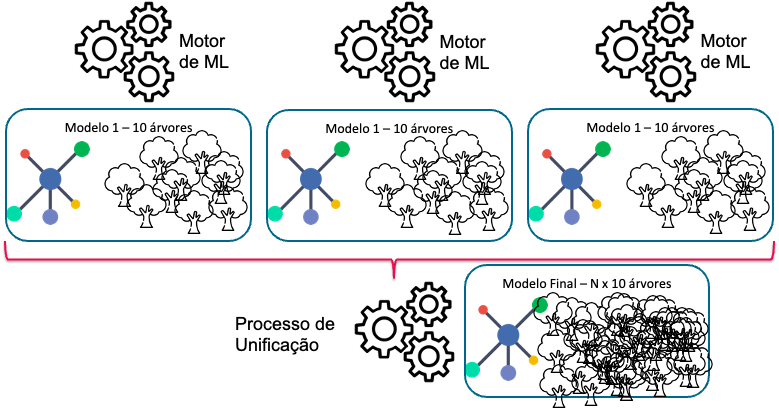

# Atividade

Gere 12 florestas (modelos do tipo Random Forest Regressor) para um décimo dos dados disponíveis na base de treino
- Cada floresta só pode possuir 10 árvores;
- Cada floresta só pode usar a parte dos dados disponíveis que lhe é atribuída;
- Discuta com a turma alternativas para essa divisão;


Gere uma nova floresta com as árvores das florestas anteriores
- Você precisa pesquisar o código para fazer esse merge


Obtenha uma fração dos dados de teste e:
- Faça uma predição usando a floresta resultando com as 120 árvores;
- Faça uma predição usando uma floresta qualquer que você gerou;
- Calcule o Root Mean Square Error das duas florestas e avalie essa métrica nos dois casos


# Bibliotecas

In [50]:
import pandas as pd
import numpy as np
from google.cloud import bigquery
from google.oauth2 import service_account
from sklearn.ensemble import RandomForestRegressor

# Autenticação do Colab com o Bigquery

In [51]:
from google.colab import auth
auth.authenticate_user()

In [52]:
#@title Preenchimento do código do projeto
#@markdown Preencha abaixo o código do teu projeto na GCP. <br/>
#@markdown Após preenchimento do código, execute essa célula.   <br/>

project_id = "fiap10dtsr-459723"  #@param {type: "string"}
#@markdown ---
clientbq = bigquery.Client(project=project_id)


A célula a seguir testa a conexão do Big Query, listando todos os datasets disponíveis.

In [53]:
for dataset in clientbq.list_datasets():
  print(dataset.dataset_id)

enem


# Treinamento de modelos Random Forest Regressor





In [54]:
#@title Parâmetros
#@markdown Preencha com os parâmetros ncessários. <br/>
#@markdown Após preenchimento do código, execute essa célula.   <br/>

#@markdown Número de florestas desejadas:
n_florestas = 12 # @param {"type":"slider","min":1,"max":20,"step":1}
#@markdown Número de árvores por floresta:
n_arvores_modelo = 15 # @param {"type":"slider","min":1,"max":100,"step":1}
#@markdown O máximo de registros deve ser de acordo com a memória do computador, mas é interessante iniciar os testes com um valor menor:
n_maximo_registros = 10000 # @param {"type":"number"}
#@markdown ---
clientbq = bigquery.Client(project=project_id)

Features constantes.
Coloque aqui a declaração das features, pois as mesmas serão iguais em todas as árvores.

In [55]:
query_sql = f"""
  SELECT *
  FROM `{project_id}.enem.ml_treino`
  LIMIT {n_maximo_registros}
"""
df_treino = clientbq.query(query_sql).to_dataframe()

treino_X = df_treino.drop(columns=["NU_NOTA_MT"])
treino_y = df_treino["NU_NOTA_MT"]

In [56]:
query_sql = f"""
  SELECT *
  FROM `{project_id}.enem.ml_teste`
  LIMIT {n_maximo_registros}
"""
df_teste = clientbq.query(query_sql).to_dataframe()

teste_X = df_teste.drop(columns=["NU_NOTA_MT"])
teste_y = df_teste["NU_NOTA_MT"]

## Dados de Treinamento
Antes de prosseguir, exiba uma amostra dos dados


In [57]:
teste_X.head()

,ID,NU_ANO,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,...,Q023,Q024,Q025,Q026,Q027,TP_ESTADO_CIVIL,TP_COR_RACA,TP_ESCOLA,CO_UF_PROVA,rand_bucket
0,663619,2020,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,3,1,23,10
1,164739,2020,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,3,2,22,14
2,8452666,2020,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,1,35,17
3,9801607,2020,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,2,2,29,10
4,435493,2020,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,3,1,22,6


In [58]:
treino_X.head()

,ID,NU_ANO,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,...,Q023,Q024,Q025,Q026,Q027,TP_ESTADO_CIVIL,TP_COR_RACA,TP_ESCOLA,CO_UF_PROVA,rand_bucket
0,2096522,2020,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,4,1,35,99
1,7334403,2020,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,3,2,53,33
2,5240486,2020,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,3,1,23,59
3,6025636,2020,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2,3,1,32,68
4,1874224,2020,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2,2,1,29,22


## Treinamento Paralelo

Insira os códigos necessários para gerar as florestas. Considere que o código poderia gerar florestas em computadores distintos.

In [59]:
florestas = []
for i in range(n_florestas):
    percentage = 100 / n_florestas
    id_init = (i * n_maximo_registros) + 1
    id_end = (i + 1) * n_maximo_registros
    query_sql = f"""
      SELECT *
      FROM `{project_id}.enem.ml_treino`
      WHERE ID BETWEEN {id_init} AND {id_end}
    """
    df_treino = clientbq.query(query_sql).to_dataframe()

    treino_X = df_treino.drop(columns=["NU_NOTA_MT"]).values
    treino_y = df_treino["NU_NOTA_MT"].values

    rf = RandomForestRegressor(n_estimators=n_arvores_modelo, random_state=42)
    rf.fit(treino_X, treino_y)
    florestas.append(rf)

# Combinação das Florestas

Insira os códigos necessários para combinar as florestas.

In [60]:
combined_forest = RandomForestRegressor(n_estimators=0, random_state=42)
combined_forest.estimators_ = [tree for forest in florestas for tree in forest.estimators_]
combined_forest.n_estimators = len(combined_forest.estimators_)

In [62]:
# 5. Combinar as árvores de todas as florestas em uma nova floresta com 120 árvores
# Pegamos todos os estimators (árvores individuais) e passamos para uma nova floresta
todas_arvores = []
for rf in florestas:
    todas_arvores.extend(rf.estimators_)

floresta_120 = RandomForestRegressor(n_estimators=120)
floresta_120.estimators_ = todas_arvores
floresta_120.n_estimators = len(todas_arvores)
floresta_120.estimators_ = todas_arvores  # sobrescreve os estimators novamente após fit

In [63]:
floresta_120

RandomForestRegressor(n_estimators=180)

# Teste / Validação

Obtenha uma amostra de dados de teste

In [71]:
floresta_120.n_outputs_ = rf.n_outputs_


In [72]:
y_pred_combined = floresta_120.predict(teste_X.values)
y_pred_individual = florestas[0].predict(teste_X.values)

## Métricas
- Faça uma predição usando a floresta resultando com as 120 árvores;  
- Faça uma predição usando uma floresta qualquer que você gerou;  
- Calcule o Root Mean Square Error das duas florestas e avalie essa métrica nos dois casos


In [73]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_combined = np.sqrt(mean_squared_error(teste_y, y_pred_combined))
rmse_individual = np.sqrt(mean_squared_error(teste_y, y_pred_individual))

In [74]:
print(f"RMSE da floresta combinada: {rmse_combined}")
print(f"RMSE de uma floresta individual: {rmse_individual}")

RMSE da floresta combinada: 87.40170327007591
RMSE de uma floresta individual: 92.92335975078242
